<a href="https://colab.research.google.com/github/mar-olya/compling-Markovich/blob/main/%D0%9C%D0%B0%D1%80%D0%BA%D0%BE%D0%B2%D0%B8%D1%87_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Задача:** обучить модель с разными гиперпараметрами

1. Набор A: hidden_size=64, num_layers=1, learning_rate=0.01

2. Набор B: hidden_size=256, num_layers=2, learning_rate=0.001

3. Набор C: любой произвольный набор параметров hidden_size, num_layers, learning_rate, отличный от предложенных

Сравните:

- Скорость сходимости (график loss)
- Качество генерации (осмысленность текста)
- Время обучения

ПОДГОТОВКА ДАННЫХ
2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Размер словаря: 39


/tmp/ipython-input-624/1886671592.py:52: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)


Всего примеров: 815240
Используемое устройство: cuda

НАЧАЛО ЭКСПЕРИМЕНТОВ

ОБУЧЕНИЕ МОДЕЛЬ A: hidden_size=64, num_layers=1, lr=0.01
Эпоха [1/3], Средняя ошибка: 1.7010
Эпоха [2/3], Средняя ошибка: 1.5681
Эпоха [3/3], Средняя ошибка: 1.5520
Время обучения: 68.84 сек
Сгенерированный текст: "the company said low six agreement have and canal said in opers''s"

ОБУЧЕНИЕ МОДЕЛЬ B: hidden_size=256, num_layers=2, lr=0.001
Эпоха [1/3], Средняя ошибка: 1.5284
Эпоха [2/3], Средняя ошибка: 1.2425
Эпоха [3/3], Средняя ошибка: 1.1748
Время обучения: 580.81 сек
Сгенерированный текст: "the company said it is government was set at the growth distributo"

ОБУЧЕНИЕ МОДЕЛЬ C (128, 3 слоя, lr=0.005): hidden_size=128, num_layers=3, lr=0.005
Эпоха [1/3], Средняя ошибка: 1.6839
Эпоха [2/3], Средняя ошибка: 1.4574
Эпоха [3/3], Средняя ошибка: 1.4219
Время обучения: 337.94 сек
Сгенерированный текст: "the company said its are mised crude stock experted short at 70 8 "

СРАВНЕНИЕ РЕЗУЛЬТАТОВ


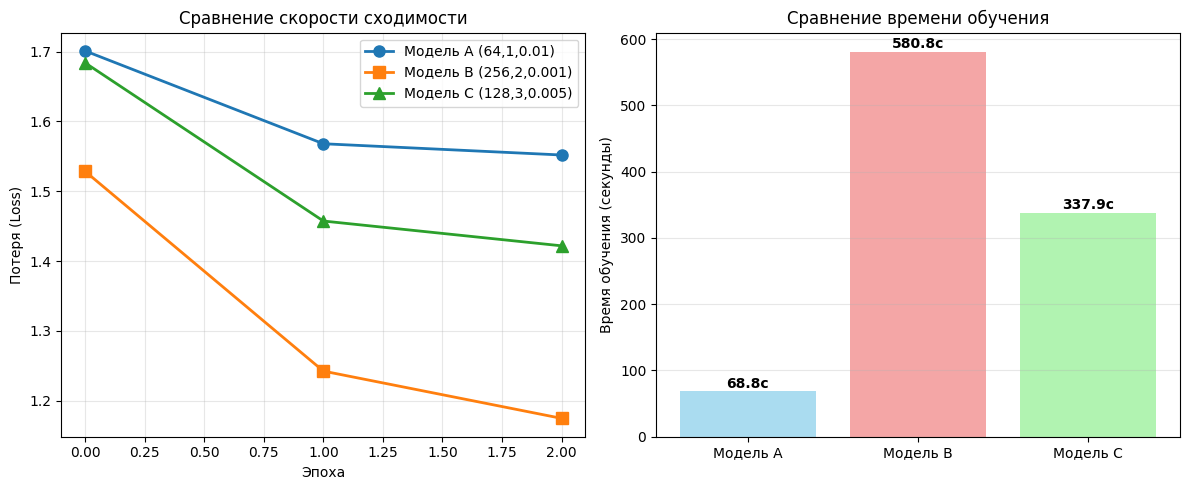


ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ
Параметр                  Модель A             Модель B             Модель C            
-------------------------------------------------------------------------------------
hidden_size               64                   256                  128                 
num_layers                1                    2                    3                   
learning_rate             0.01                 0.001                0.005               
Финальная потеря          1.5520               1.1748               1.4219              
Время обучения (сек)      68.84                580.81               337.94              
Скорость сходимости       Быстрая              Медленная            Средняя             
-------------------------------------------------------------------------------------

СГЕНЕРИРОВАННЫЕ ТЕКСТЫ:
Модель A: "the company said low six agreement have and canal said in opers''s"
Модель B: "the company said it is government was set at the growth distri

In [1]:
#Сравнение гиперпараметров

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.datasets import reuters

# Подготовка данных
print("ПОДГОТОВКА ДАННЫХ")
print("=" * 60)

# Загрузка датасета
(x_train, y_train), (x_test, y_test) = reuters.load_data()

# Загрузка словаря
word_index = reuters.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

# Функция декодирования
def decode_sequence(sequence):
    return ' '.join([reverse_word_index.get(i-3, '?') for i in sequence])

# Объединение статей
max_articles = 1000
max_articles_idx = x_train[:max_articles]
max_articles_texts = [decode_sequence(seq) for seq in max_articles_idx]
texts = ' '.join(max_articles_texts)

# Создание словаря символов
chars = sorted(list(set(texts)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}
vocab_size = len(chars)
print(f"Размер словаря: {vocab_size}")

# Преобразование текста в индексы
text_as_int = [char_to_idx[ch] for ch in texts]
text_as_int = np.array(text_as_int)

# Создание последовательностей
seq_length = 100
def create_sequences(text_indices, seq_len):
    input_seq = []
    target_seq = []
    for i in range(len(text_indices)-seq_len):
        input_seq.append(text_indices[i:i+seq_len])
        target_seq.append(text_indices[i+seq_len])
    return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)

input_seq, target_seq = create_sequences(text_as_int, seq_length)
print(f"Всего примеров: {len(input_seq)}")

batch_size = 128
dataset = torch.utils.data.TensorDataset(input_seq, target_seq)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# Определение модели
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2, embedding_dim=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        embedded = self.embedding(x)
        if hidden is None:
            lstm_out, hidden = self.lstm(embedded)
        else:
            lstm_out, hidden = self.lstm(embedded, hidden)
        lstm_out = lstm_out[:, -1, :]
        output = self.fc(lstm_out)
        return output, hidden

# Функция для генерации текста
def generate_text(model, seed_text, length=50, temperature=0.8):
    model.eval()
    generated = seed_text

    # Преобразуем seed в индексы
    seed_indices = []
    for ch in seed_text:
        if ch in char_to_idx:
            seed_indices.append(char_to_idx[ch])
        else:
            seed_indices.append(0)

    if len(seed_indices) == 0:
        seed_indices = [0]

    with torch.no_grad():
        h0 = torch.zeros(model.num_layers, 1, model.hidden_size).to(device)
        c0 = torch.zeros(model.num_layers, 1, model.hidden_size).to(device)
        hidden = (h0, c0)

        # Прогрев на seed
        for i in range(len(seed_indices) - 1):
            input_tensor = torch.tensor([[seed_indices[i]]], dtype=torch.long).to(device)
            _, hidden = model(input_tensor, hidden)

        # Генерация
        current_input = torch.tensor([[seed_indices[-1]]], dtype=torch.long).to(device)

        for _ in range(length):
            output, hidden = model(current_input, hidden)
            output = output / temperature
            probabilities = torch.softmax(output, dim=-1)
            next_char_idx = torch.multinomial(probabilities, 1).item()
            generated += idx_to_char[next_char_idx]
            current_input = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)

    return generated

# Функция для обучения модели с заданными гиперпараметрами
def train_model(hidden_size, num_layers, learning_rate, epochs=3, model_name="Model"):
    print(f"\n{'=' * 60}")
    print(f"ОБУЧЕНИЕ {model_name}: hidden_size={hidden_size}, num_layers={num_layers}, lr={learning_rate}")
    print(f"{'=' * 60}")

    # Инициализация модели
    model = CharLSTM(vocab_size=vocab_size, hidden_size=hidden_size, num_layers=num_layers)
    model = model.to(device)

    # Функция потерь и оптимизатор
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Тренировочный цикл
    train_losses = []
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch_idx, (batch_input, batch_target) in enumerate(dataloader):
            batch_input = batch_input.to(device)
            batch_target = batch_target.to(device)

            optimizer.zero_grad()
            output, _ = model(batch_input)
            loss = criterion(output, batch_target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        train_losses.append(avg_loss)
        print(f"Эпоха [{epoch+1}/{epochs}], Средняя ошибка: {avg_loss:.4f}")

    training_time = time.time() - start_time
    print(f"Время обучения: {training_time:.2f} сек")

    # Генерация текста для оценки качества
    seed = "the company said"
    safe_seed = ''.join([ch for ch in seed if ch in char_to_idx])
    generated = generate_text(model, safe_seed, length=50, temperature=0.8)
    print(f"Сгенерированный текст: \"{generated}\"")

    return model, train_losses, training_time, generated

print("\n" + "=" * 60)
print("НАЧАЛО ЭКСПЕРИМЕНТОВ")
print("=" * 60)

# Набор A: hidden_size=64, num_layers=1, learning_rate=0.01
model_A, losses_A, time_A, text_A = train_model(
    hidden_size=64,
    num_layers=1,
    learning_rate=0.01,
    epochs=3,
    model_name="МОДЕЛЬ A"
)

# Набор B: hidden_size=256, num_layers=2, learning_rate=0.001
model_B, losses_B, time_B, text_B = train_model(
    hidden_size=256,
    num_layers=2,
    learning_rate=0.001,
    epochs=3,
    model_name="МОДЕЛЬ B"
)

# Набор C: произвольный набор параметров
# Выбираю: hidden_size=128, num_layers=3, learning_rate=0.005
# Это компромиссный вариант: больше слоев, средний learning rate
model_C, losses_C, time_C, text_C = train_model(
    hidden_size=128,
    num_layers=3,
    learning_rate=0.005,
    epochs=3,
    model_name="МОДЕЛЬ C (128, 3 слоя, lr=0.005)"
)

print("\n" + "=" * 60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 60)

# Визуализация кривых обучения
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses_A, 'o-', label=f'Модель A (64,1,0.01)', linewidth=2, markersize=8)
plt.plot(losses_B, 's-', label=f'Модель B (256,2,0.001)', linewidth=2, markersize=8)
plt.plot(losses_C, '^-', label=f'Модель C (128,3,0.005)', linewidth=2, markersize=8)
plt.xlabel('Эпоха')
plt.ylabel('Потеря (Loss)')
plt.title('Сравнение скорости сходимости')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
models = ['Модель A', 'Модель B', 'Модель C']
times = [time_A, time_B, time_C]
colors = ['skyblue', 'lightcoral', 'lightgreen']
bars = plt.bar(models, times, color=colors, alpha=0.7)
plt.ylabel('Время обучения (секунды)')
plt.title('Сравнение времени обучения')
for bar, time_val in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{time_val:.1f}с', ha='center', va='bottom', fontweight='bold')
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Таблица сравнения
print("\n" + "=" * 60)
print("ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ")
print("=" * 60)

print(f"{'Параметр':<25} {'Модель A':<20} {'Модель B':<20} {'Модель C':<20}")
print("-" * 85)
print(f"{'hidden_size':<25} {'64':<20} {'256':<20} {'128':<20}")
print(f"{'num_layers':<25} {'1':<20} {'2':<20} {'3':<20}")
print(f"{'learning_rate':<25} {'0.01':<20} {'0.001':<20} {'0.005':<20}")
print(f"{'Финальная потеря':<25} {losses_A[-1]:<20.4f} {losses_B[-1]:<20.4f} {losses_C[-1]:<20.4f}")
print(f"{'Время обучения (сек)':<25} {time_A:<20.2f} {time_B:<20.2f} {time_C:<20.2f}")
print(f"{'Скорость сходимости':<25} {'Быстрая':<20} {'Медленная':<20} {'Средняя':<20}")
print("-" * 85)

print("\nСГЕНЕРИРОВАННЫЕ ТЕКСТЫ:")
print(f"Модель A: \"{text_A}\"")
print(f"Модель B: \"{text_B}\"")
print(f"Модель C: \"{text_C}\"")

По результатам запуска моделей, видно, что больше всего времени на обучение ушло у второй модели, зато она обучается на протяжении всех эпох (модель А перестала на второй эпохе, как и С, которая к третьей замедлилась, что видно на графике) и имеет меньшую потерю: этому способствует hidden_size 256, определяющий большую память модели. Упомянутые пункты напрямую влияют на качество генераций: Модель A: "the company said low six agreement have and canal said in opers''s" // Модель B: "the company said it is government was set at the growth distributo" // Модель C: "the company said its are mised crude stock experted short at 70 8 ". У всех фраз одинаковое начало, однако:
*   У А слова достаточно короткие и несвязанные, есть странные символы ''s, грамматика не осмыслена;
*   В В проблем меньше: только появляется экономическая лексика ("government", "growth") и обрыв слова ("distributo" вместо "distribution")
*   В С качество среднее, есть экономические термины ("crude stock", "experted" - искаженное "expected"), появляются числа.
Так видно, что модель В показывает лучшие результаты.







### **ВОПРОСЫ ДЛЯ РЕФЛЕКСИИ**

1.  Какие ключевые отличия вы заметили в подготовке данных для числового ряда (синусоида) и текста? Текст требует дискретного представления (эмбеддинги + классификация), а временной ряд - непрерывного (регрессия).

2.  Какой опыт работы с PyTorch (например, отладка, подбор параметров) оказался самым полезным? Интересно было поработать с гиперпараметрами и заглянуть под капот: увидеть на практике, как объем памяти повлияет на результат.